## Setup

In [ ]:
# libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [316]:
# config

sns.set_theme(
    palette='Set2'
)

plt.rcParams.update({
    "font.family": "Trebuchet MS",
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# Make barplot
def makeBarplot(data, x, xLabel, y, yLabel, title, graphHue=None, bar_label_format="%g", color=None):
    plt.figure(figsize=(10, 6))
    graph = sns.barplot(data=data, x=x, y=y, hue=graphHue, color=color)

    # make labels for each bar
    for i in graph.containers:
        graph.bar_label(i, fmt=bar_label_format, padding=5)
    
    makeGraphAttribut(
        graph=graph, 
        xLabel=xLabel, 
        yLabel=yLabel, 
        title=title
    )
    return graph

# make title label
def makeTitle(title):
    plt.title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=20
    )

# Set attributs in graph
def makeGraphAttribut(graph,  xLabel, yLabel, title):
    graph.set_xlabel(xLabel, fontweight='bold', fontsize=12)
    graph.set_ylabel(yLabel, fontweight='bold', fontsize=12)
    graph.set_title(title, fontweight='bold', fontsize=15, pad=20)

# Make percentage text label in pie chart
def makePctLabel(pct_texts, colour='white'):
    for pct in pct_texts:
        pct.set_color(colour)
        pct.set_fontweight('bold')

In [317]:
# import files

# table after FULL OUTER JOIN of OC and INSEE
df_full = pd.read_csv('fct_full_join.csv')

# table with only analysis
df_analyse = pd.read_csv('analyse.csv')

In [318]:
df_full.head()

,YEAR,REGION,AGE_GROUP,GENDER,NB_ETUDIANTS,POPULATION_INSEE
0,2022,Auvergne-Rhône-Alpes,20-24 ans,F,NaN,228531.0
1,2022,Auvergne-Rhône-Alpes,20-24 ans,M,1.0,239255.0
2,2022,Auvergne-Rhône-Alpes,25-29 ans,F,4.0,227869.0
3,2022,Auvergne-Rhône-Alpes,25-29 ans,M,8.0,229782.0
4,2022,Auvergne-Rhône-Alpes,25-29 ans,Non renseigné,11.0,NaN


In [319]:
df_analyse.head()

,YEAR,NB_ETUDIANTS,PCT_FEMMES_OC,PCT_FEMMES_INSEE,PCT_HOMMES_OC,PCT_HOMMES_INSEE,PCT_NON_RENSEIGNE,AGE_GROUP_MAJORITAIRE,PCT_AGE_GROUP_MAJORITAIRE,REGION_MAJORITAIRE,PCT_REGION_MAJORITAIRE
0,2022,1696,17.807,52.430,40.566,47.570,41.627,30-34 ans,27.123,Île-de-France,44.929
1,2023,1150,21.478,52.398,44.609,47.602,33.913,30-34 ans,27.565,Île-de-France,54.087
2,2024,850,25.529,52.364,64.353,47.636,10.118,25-29 ans,25.059,Île-de-France,40.588
3,2025,951,30.599,52.329,62.671,47.671,6.730,30-34 ans,23.344,Île-de-France,41.115


## 1. Vue d'ensemble — Evolution globale
- 📊 Bar/line chart: nombre d'étudiants par année
- 💡 Insight: la filière Data croît-elle ou décline-t-elle ?

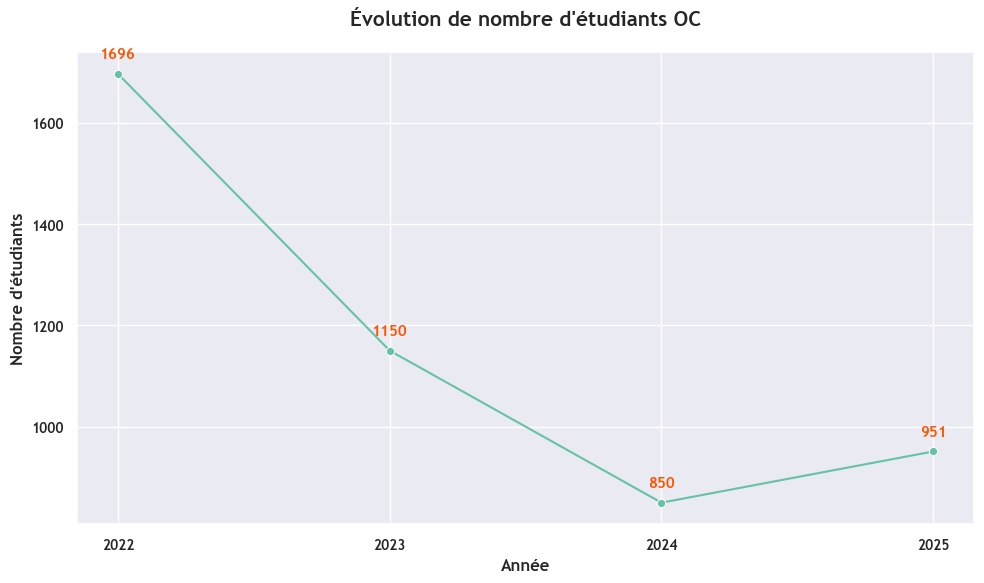

In [320]:
plt.figure(figsize=(10, 6))
plt.xticks(df_analyse.YEAR)

graph = sns.lineplot(
    df_analyse,
    x='YEAR',
    y='NB_ETUDIANTS',
    marker='o'
)

makeGraphAttribut(
    graph=graph,
    xLabel="Année",
    yLabel="Nombre d'étudiants",
    title="Évolution de nombre d'étudiants OC"
)

for x, y in zip(df_analyse.YEAR, df_analyse.NB_ETUDIANTS):
    plt.text(x, y+25, f"{(y):.0f}", ha='center', va='bottom', fontdict={'size': 11, 'color': "#fc5603"})

plt.tight_layout()
plt.show()

## 2. Analyse par genre
- 📊 Stacked bar: répartition F/M/Non renseigné par année
- 📊 Line chart: évolution du % de femmes OC vs % de femmes INSEE
- 💡 Insight: parité en progression ? sous-représentation féminine ?

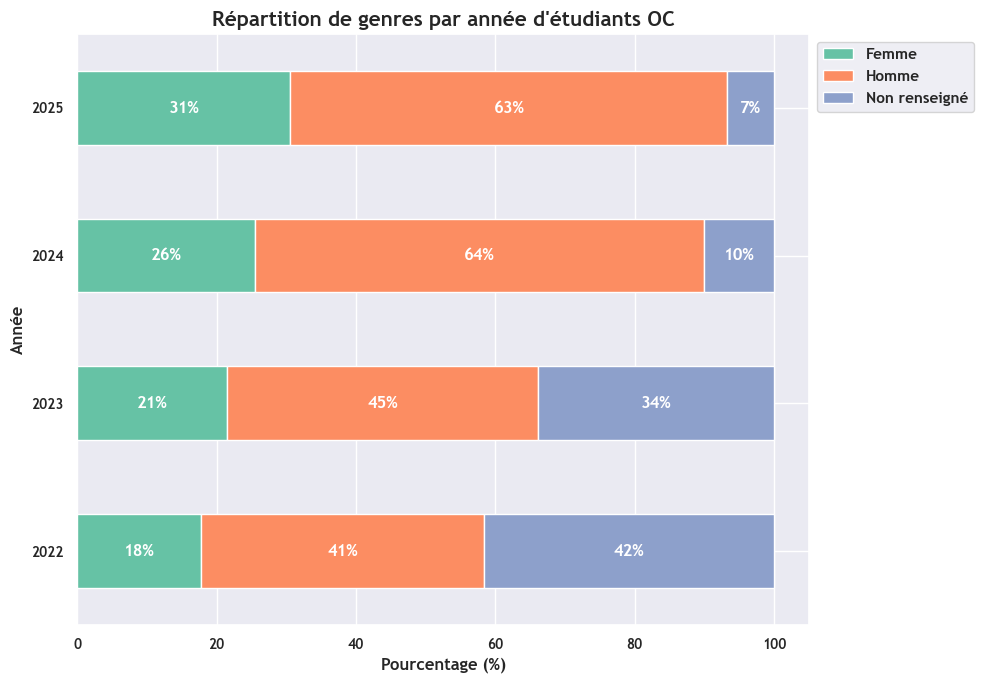

In [321]:
# Répartition de sexes
df_rep_gender = df_analyse[['YEAR', 'PCT_FEMMES_OC', 'PCT_HOMMES_OC', 'PCT_NON_RENSEIGNE']].set_index('YEAR')


ax = df_rep_gender.plot(
    kind='barh',
    stacked=True,
    ylabel='Année',
    xlabel='Pourcentage (%)',
    title="Répartition de genres par année d'étudiants OC",
    figsize=(10, 7)
)

# make percentage labels inside the bars
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f%%', label_type='center', color='white', fontweight='bold')

plt.legend(loc='best', bbox_to_anchor=(1, 1), labels=['Femme', 'Homme', 'Non renseigné'])
plt.tight_layout()
plt.show()

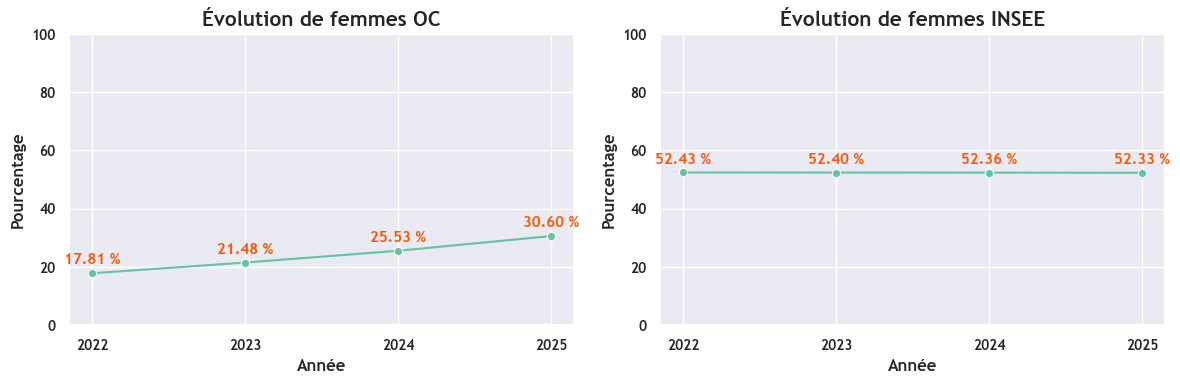

In [322]:
# Évolution du % de femmes OC vs. INSEE
df_f = df_analyse[['YEAR', 'PCT_FEMMES_OC', 'PCT_FEMMES_INSEE']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(
    df_f,
    x='YEAR',
    y='PCT_FEMMES_OC',
    ax=axes[0],
    marker='o'
)
axes[0].set_title('Évolution de femmes OC')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Pourcentage')
axes[0].set_ylim(0, 100)
axes[0].set_xticks(df_analyse.YEAR)

for x, y in zip(df_f.YEAR, df_f.PCT_FEMMES_OC):
    axes[0].text(x, y+2, f"{(y):.2f} %", ha='center', va='bottom', fontdict={'size': 11, 'color': "#fc5603"})

sns.lineplot(
    df_f,
    x='YEAR',
    y='PCT_FEMMES_INSEE',
    ax=axes[1],
    marker='o'
)
axes[1].set_title('Évolution de femmes INSEE')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Pourcentage')
axes[1].set_ylim(0, 100)
axes[1].set_xticks(df_analyse.YEAR)

for x, y in zip(df_f.YEAR, df_f.PCT_FEMMES_INSEE):
    axes[1].text(x, y+2, f"{(y):.2f} %", ha='center', va='bottom', fontdict={'size': 11, 'color': "#fc5603"})

plt.tight_layout()
plt.show()

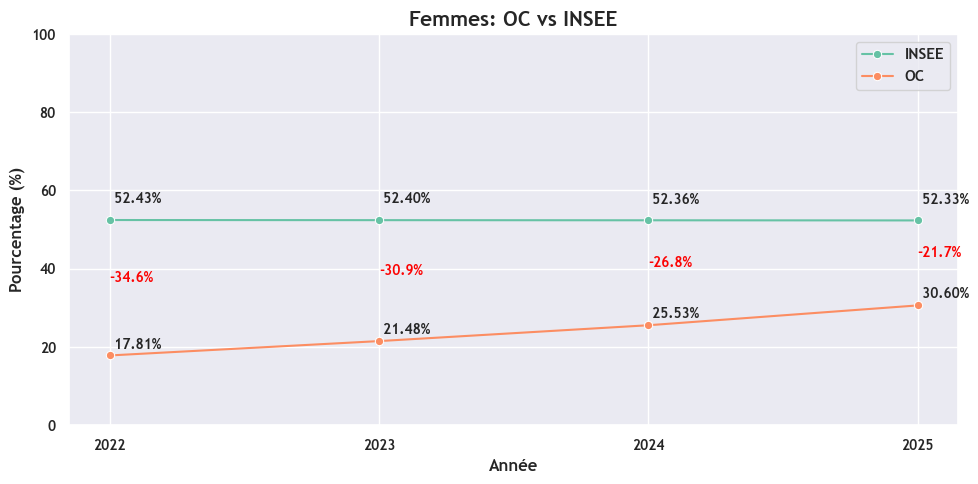

In [323]:
# Évolution du % de femmes OC vs. INSEE ensemble

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(df_f, x='YEAR', y='PCT_FEMMES_INSEE',  ax=ax, marker='o', label='INSEE')
sns.lineplot(df_f, x='YEAR', y='PCT_FEMMES_OC',    ax=ax, marker='o', label='OC')

ax.set_title('Femmes: OC vs INSEE')
ax.set_xlabel('Année')
ax.set_ylabel('Pourcentage (%)')
ax.set_ylim(0, 100)
ax.set_xticks(df_f.YEAR)

# Point labels
for _, row in df_f.iterrows():
    ax.annotate(f"{row['PCT_FEMMES_OC']: .2f}%",
                xy=(row['YEAR'], row['PCT_FEMMES_OC']),
                xytext=(0, 5), textcoords='offset points', fontsize=10)
    ax.annotate(f"{row['PCT_FEMMES_INSEE']: .2f}%",
                xy=(row['YEAR'], row['PCT_FEMMES_INSEE']),
                xytext=(0, 12), textcoords='offset points', fontsize=10)

# Gap label between the two lines
for _, row in df_f.iterrows():
    gap = round(row['PCT_FEMMES_INSEE'] - row['PCT_FEMMES_OC'], 1)
    mid_y = (row['PCT_FEMMES_OC'] + row['PCT_FEMMES_INSEE']) / 2
    ax.annotate(f"-{gap}%",
                xy=(row['YEAR'], mid_y),
                xytext=(0, 4), textcoords='offset points',  # offset from xy
                fontsize=10, color="#fc0303")

plt.legend()
plt.tight_layout()
plt.show()

## 3. Analyse par âge
- 📊 Bar chart: répartition par tranche d'âge (toutes années confondues)
- 📊 Heatmap: tranche d'âge × année (pour voir l'évolution)
- 📊 Comparaison OC vs INSEE par tranche d'âge
- 💡 Insight: profil de reconversion (30-39 ans dominant ?)

<Axes: title={'center': "Répartition par tranche d'âge (étudiants OC)"}, xlabel="Tranche d'âge", ylabel="Nombre d'étudiants">

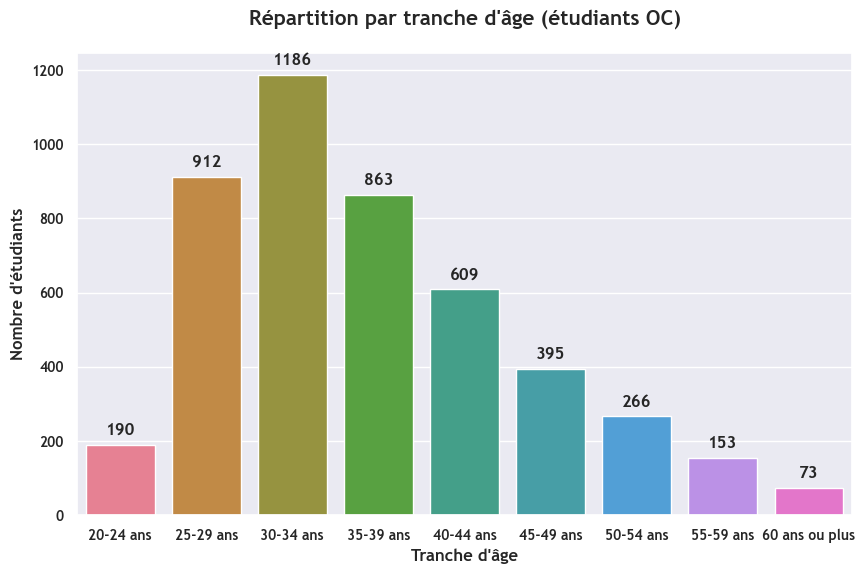

In [324]:
# Distribution of age group of students OC

df_age_group = df_full.groupby('AGE_GROUP')['NB_ETUDIANTS'].sum().reset_index()

makeBarplot(
    df_age_group,
    x='AGE_GROUP',
    xLabel="Tranche d'âge",
    y='NB_ETUDIANTS',
    yLabel="Nombre d'étudiants",
    title="Répartition par tranche d'âge (étudiants OC)",
    graphHue='AGE_GROUP'
)

<Axes: title={'center': "Répartition par tranche d'âge (étudiants OC)"}, xlabel="Tranche d'âge", ylabel='Pourcentage (%)'>

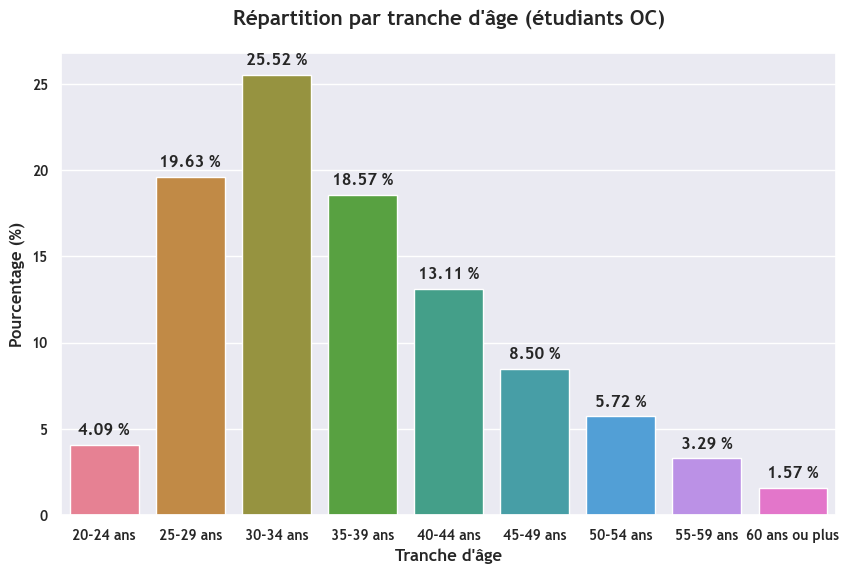

In [325]:
# Distribution of age group of students OC by %

df_age_group_pct = df_full.groupby('AGE_GROUP')['NB_ETUDIANTS'].sum().reset_index()
df_age_group_pct['pct'] = (df_age_group_pct.NB_ETUDIANTS * 100 / df_age_group_pct.NB_ETUDIANTS.sum()).round(2)

makeBarplot(
    df_age_group_pct,
    x='AGE_GROUP',
    xLabel="Tranche d'âge",
    y='pct',
    yLabel="Pourcentage (%)",
    title="Répartition par tranche d'âge (étudiants OC)",
    graphHue='AGE_GROUP',
    bar_label_format="%.2f %%"
)

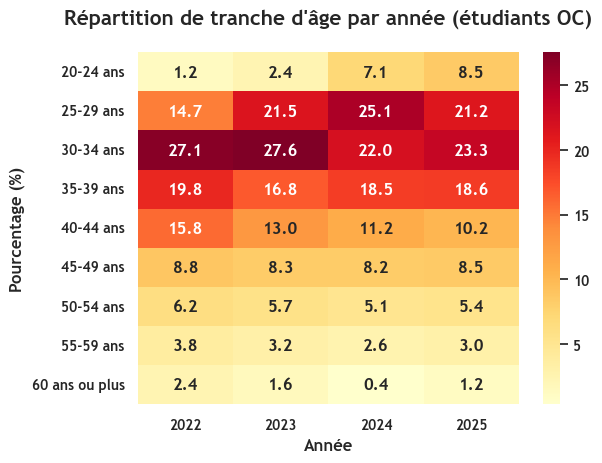

In [326]:
# Heatmap by year and age group of OC

df_age_year = df_full.groupby(['YEAR', 'AGE_GROUP'])['NB_ETUDIANTS'].sum().reset_index()
df_age_year = df_age_year.pivot(index='AGE_GROUP', columns='YEAR', values='NB_ETUDIANTS')
df_age_year = df_age_year.div(df_age_year.sum(axis=0), axis=1) * 100

graph = sns.heatmap(
    df_age_year,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

makeGraphAttribut(
    graph=graph,
    xLabel="Année",
    yLabel="Pourcentage (%)",
    title="Répartition de tranche d'âge par année (étudiants OC)"
)

plt.tight_layout()
plt.show()

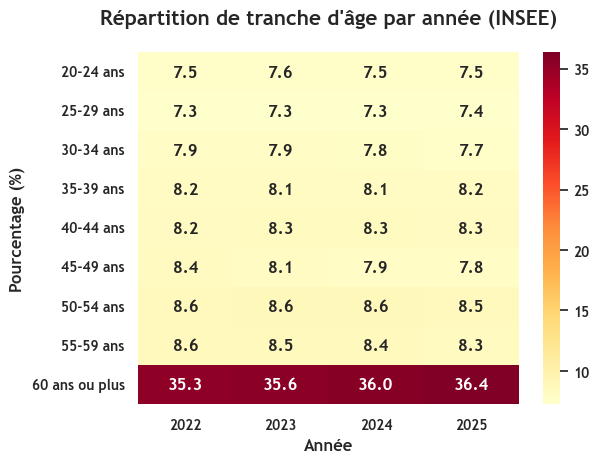

In [327]:
# Heatmap by year and age group of INSEE

df_age_year_insee = df_full.groupby(['YEAR', 'AGE_GROUP'])['POPULATION_INSEE'].sum().reset_index()
df_age_year_insee = df_age_year_insee.pivot(index='AGE_GROUP', columns='YEAR', values='POPULATION_INSEE')
df_age_year_insee = df_age_year_insee.div(df_age_year_insee.sum(axis=0), axis=1) * 100

graph = sns.heatmap(
    df_age_year_insee,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

makeGraphAttribut(
    graph=graph,
    xLabel="Année",
    yLabel="Pourcentage (%)",
    title="Répartition de tranche d'âge par année (INSEE)"
)

plt.tight_layout()
plt.show()

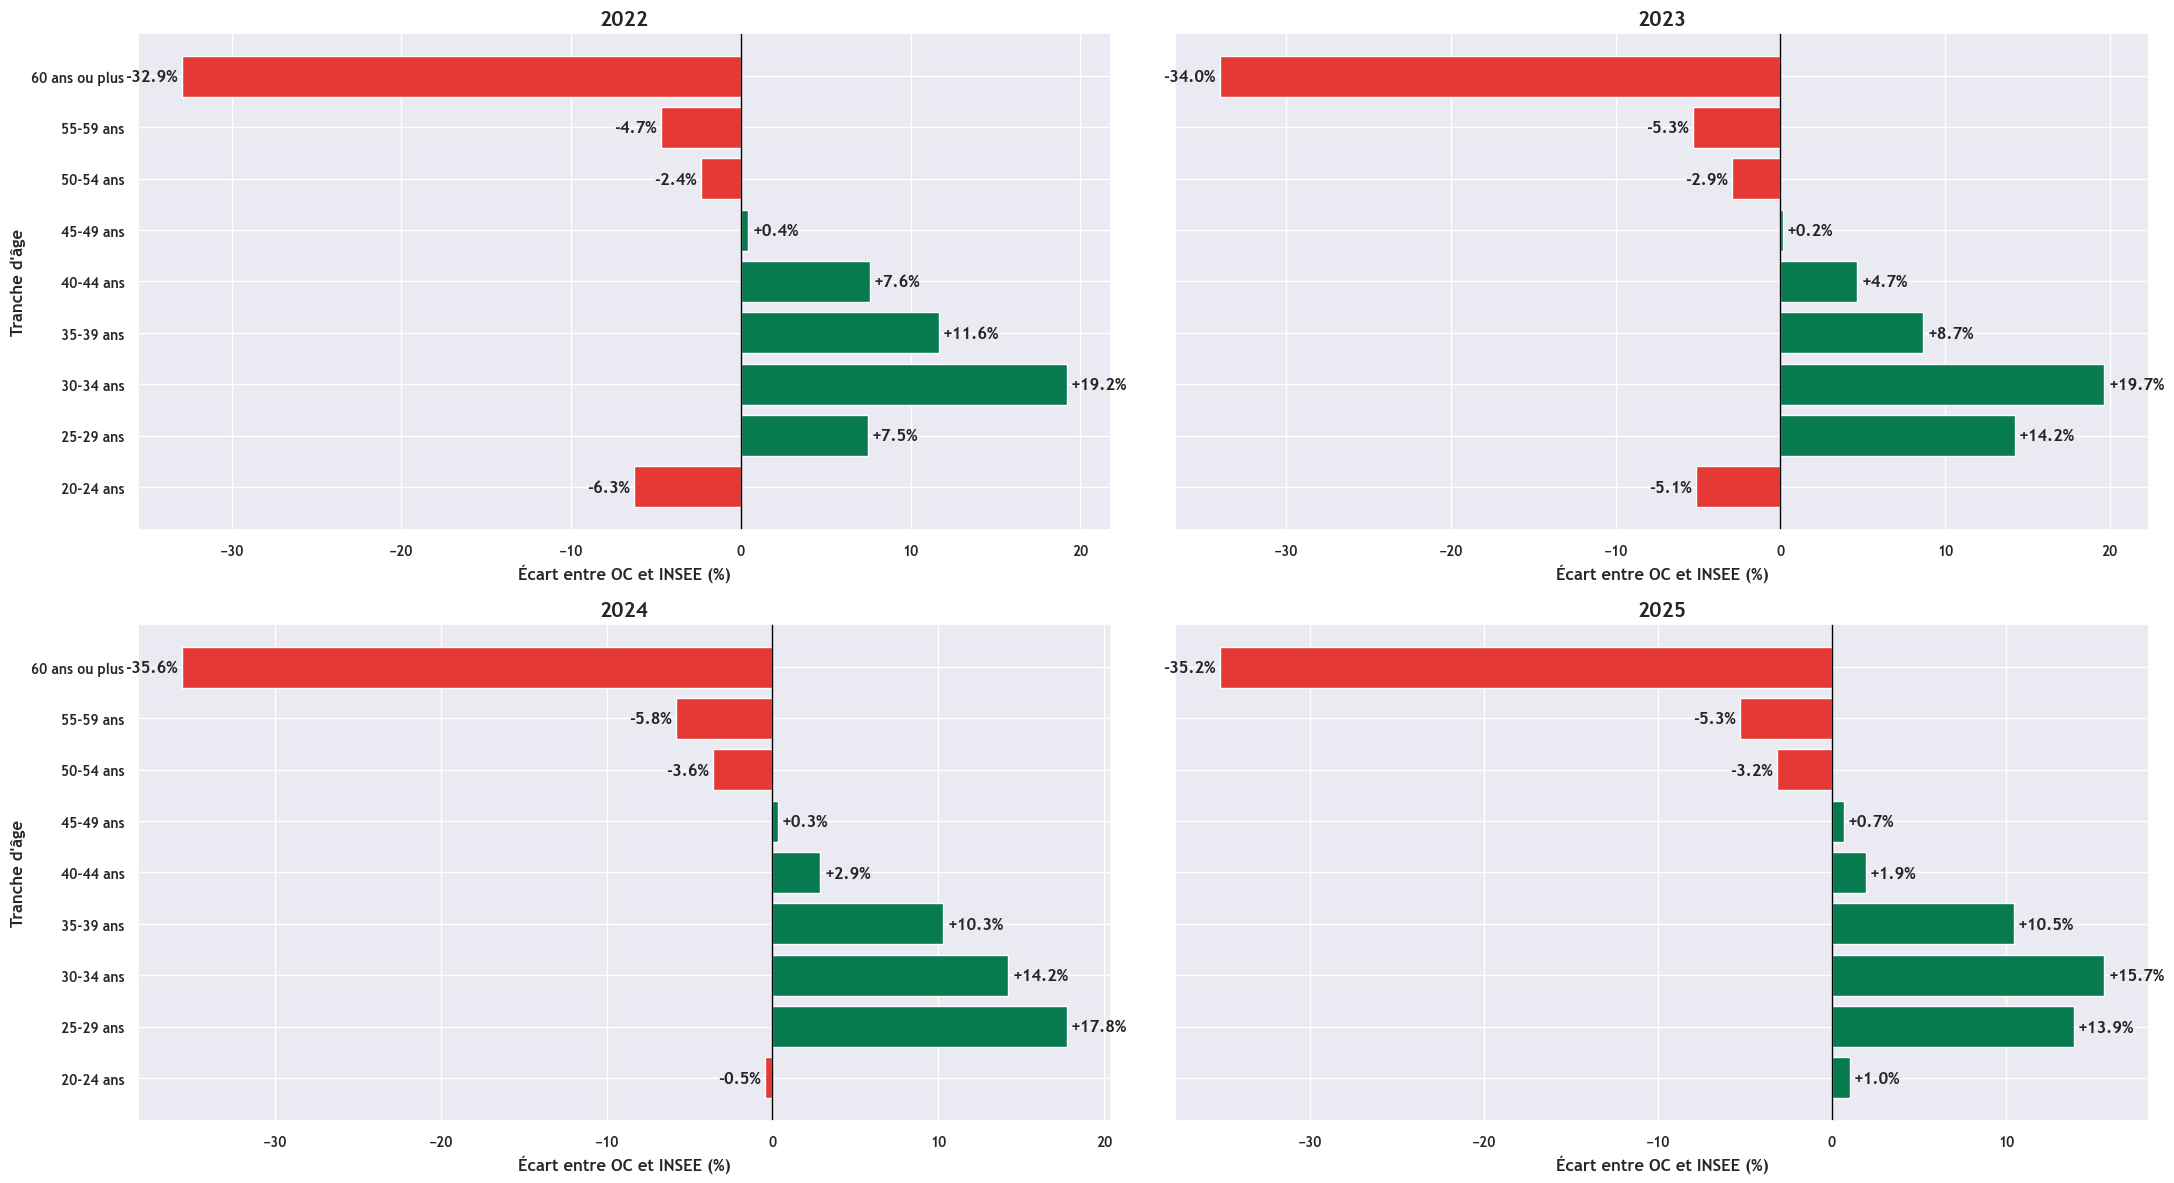

In [328]:
# Comparing age group of OC and INSEE per year

years = df_full.YEAR.unique()
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, year in zip(axes, years):
    df_age_compare = df_full.loc[df_full.YEAR == year].groupby('AGE_GROUP')[['NB_ETUDIANTS', 'POPULATION_INSEE']].sum()
    df_age_compare = df_age_compare.div(df_age_compare.sum(), axis=1) * 100
    df_age_compare['gap'] = df_age_compare.NB_ETUDIANTS - df_age_compare.POPULATION_INSEE

    colours = ["#087A50" if gap >= 0 else '#E53935' for gap in df_age_compare['gap']]

    ax.barh(
        df_age_compare.index,
        df_age_compare.gap,
        color=colours
    )
    ax.axvline(0, color='black', linewidth=1)  # central line
    ax.set_title(str(year))
    ax.set_xlabel('Écart entre OC et INSEE (%)')

    for i, val in enumerate(df_age_compare['gap']):
        ax.annotate(f'{val:+.1f}%',
                    xy=(val, i),
                    xytext=(3 if val >= 0 else -3, 0),
                    textcoords='offset points',
                    va='center',
                    ha='left' if val >= 0 else 'right',
                    fontsize=12)

axes[0].set_ylabel("Tranche d'âge")
axes[2].set_ylabel("Tranche d'âge")
plt.tight_layout()
plt.show()


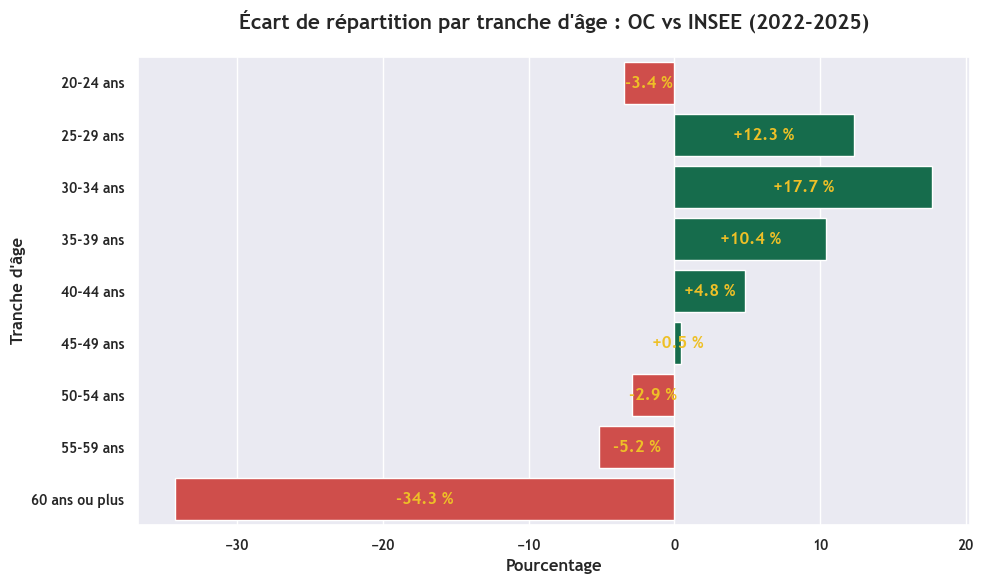

In [366]:
# Comparing age group of OC and INSEE in total (4 years)

df_age_compare_total = df_full.groupby('AGE_GROUP')[['NB_ETUDIANTS', 'POPULATION_INSEE']].sum()
df_age_compare_total = df_age_compare_total.div(df_age_compare_total.sum(), axis=1) * 100
df_age_compare_total['gap'] = df_age_compare_total.NB_ETUDIANTS - df_age_compare_total.POPULATION_INSEE

colours = ['#087A50' if g >= 0 else '#E53935' for g in df_age_compare_total['gap']]

plt.figure(figsize=(10, 6))
graph = sns.barplot(
    data=df_age_compare_total, 
    x='gap', 
    y=df_age_compare_total.index,
    hue=df_age_compare_total.index,
    palette=colours
)

for i in graph.containers:
    graph.bar_label(i, fmt="%+.1f %%", label_type='center', color="#EEC027")
    
makeGraphAttribut(
    graph=graph, 
    xLabel="Pourcentage", 
    yLabel="Tranche d'âge", 
    title="Écart de répartition par tranche d'âge : OC vs INSEE (2022-2025)"
)
    
plt.tight_layout()
plt.show()

## 4. Analyse géographique
- 📊 Bar chart: top régions par nombre d'étudiants
- 📊 Comparaison % étudiants OC vs % population INSEE par région
- 💡 Insight: Île-de-France sur-représentée ?

<Axes: title={'center': 'Répartition par région (étudiants OC)'}, xlabel='Pourcentage (%)', ylabel='Région'>

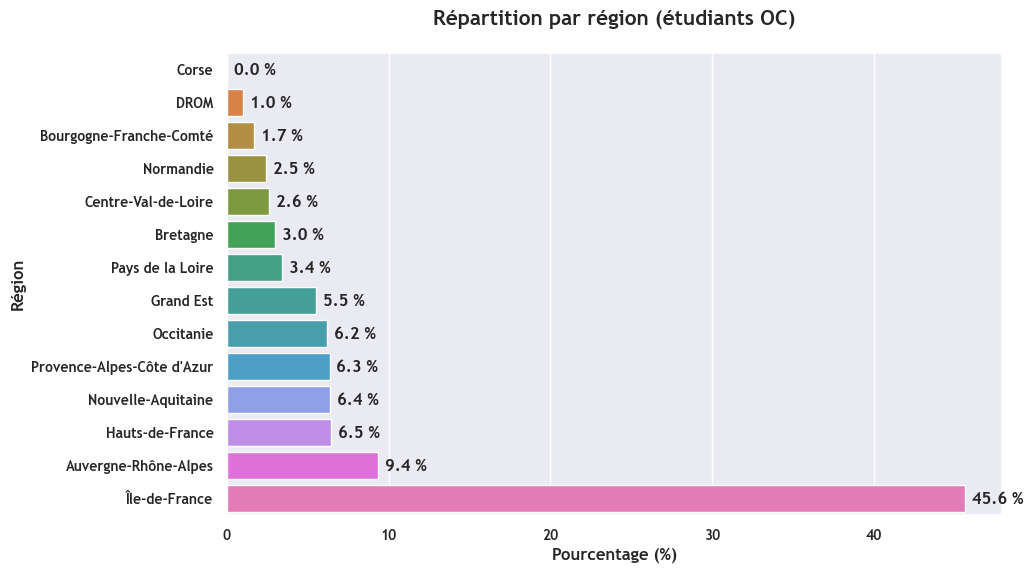

In [330]:
# Distribution of regions of students OC by %

df_region_pct = df_full.groupby('REGION')['NB_ETUDIANTS'].sum().reset_index()
df_region_pct['pct'] = (df_region_pct.NB_ETUDIANTS * 100 / df_region_pct.NB_ETUDIANTS.sum()).round(2)
df_region_pct.sort_values(by='pct', ascending=True, inplace=True)

makeBarplot(
    df_region_pct,
    x='pct',
    xLabel="Pourcentage (%)",
    y='REGION',
    yLabel="Région",
    title="Répartition par région (étudiants OC)",
    graphHue='REGION',
    bar_label_format="%.1f %%"
)

<Axes: title={'center': 'Répartition par région (Population INSEE)'}, xlabel='Pourcentage (%)', ylabel='Région'>

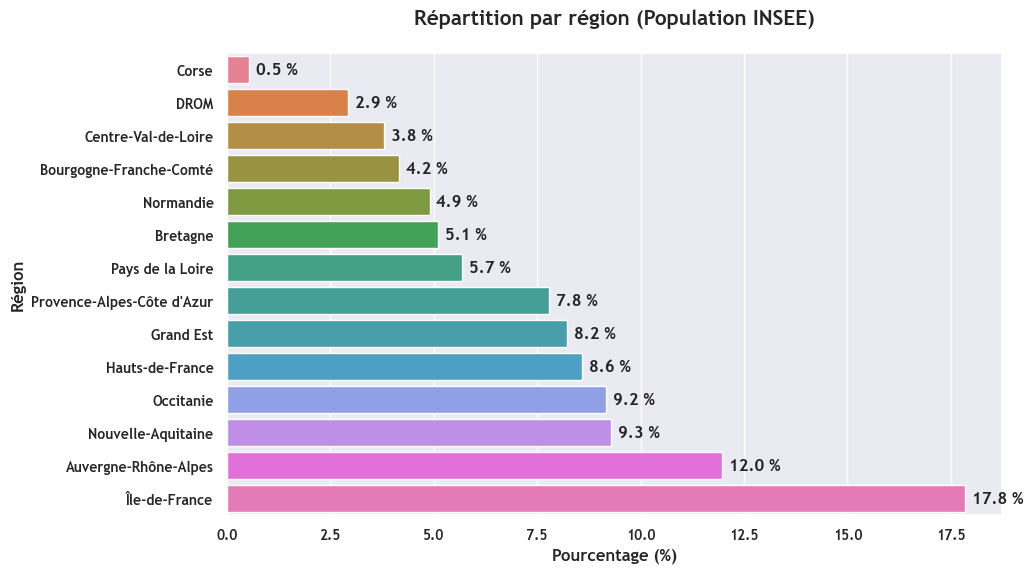

In [331]:
# Distribution of regions of INSEE by %

df_region_insee_pct = df_full.groupby('REGION')['POPULATION_INSEE'].sum().reset_index()
df_region_insee_pct['pct'] = (df_region_insee_pct.POPULATION_INSEE * 100 / df_region_insee_pct.POPULATION_INSEE.sum()).round(2)
df_region_insee_pct.sort_values(by='pct', ascending=True, inplace=True)

makeBarplot(
    df_region_insee_pct,
    x='pct',
    xLabel="Pourcentage (%)",
    y='REGION',
    yLabel="Région",
    title="Répartition par région (Population INSEE)",
    graphHue='REGION',
    bar_label_format="%.1f %%"
)

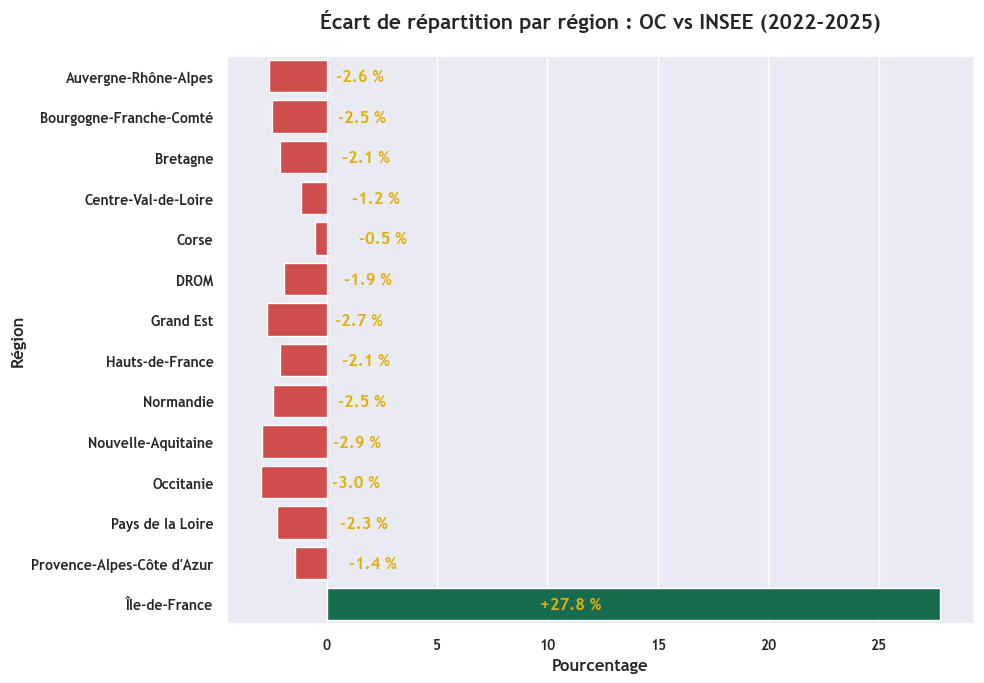

In [375]:
# Comparing regions of OC and INSEE in total (4 years)

df_region_compare_total = df_full.groupby('REGION')[['NB_ETUDIANTS', 'POPULATION_INSEE']].sum()
df_region_compare_total = df_region_compare_total.div(df_region_compare_total.sum(), axis=1) * 100
df_region_compare_total['gap'] = df_region_compare_total.NB_ETUDIANTS - df_region_compare_total.POPULATION_INSEE

colours = ['#087A50' if g >= 0 else '#E53935' for g in df_region_compare_total['gap']]

plt.figure(figsize=(10, 7))
graph = sns.barplot(
    data=df_region_compare_total, 
    x='gap', 
    y=df_region_compare_total.index,
    hue=df_region_compare_total.index,
    palette=colours
)

for i in graph.containers:
    graph.bar_label(i, fmt="%+.1f %%", padding=-45, label_type='center', color="#E1AF0C")
    
makeGraphAttribut(
    graph=graph, 
    xLabel="Pourcentage", 
    yLabel="Région", 
    title="Écart de répartition par région : OC vs INSEE (2022-2025)"
)
    
plt.tight_layout()
plt.show()

## 5. Analyse des réinscriptions
- 📊 Bar chart: nombre d'étudiants par nombre d'inscriptions
- 💡 Insight: fidélisation, abandon, reprise de formation ?

In [340]:
# Import the file with only OC data

df_oc = pd.read_csv("data_oc.csv")
df_oc.head()

,USER_ID,PATH_CATEGORY_NAME,AGE_GROUP,GENDER,REGION,YEAR_PATH_STARTED
0,U-4510146189133097827,Data,30-34 ans,F,Île-de-France,2025
1,U-3523981388172716996,Data,60 ans ou plus,M,Île-de-France,2023
2,U-554277309782049638,Data,30-34 ans,NaN,Hauts-de-France,2023
3,U682607025783480308,Data,50-54 ans,NaN,Île-de-France,2023
4,U437613285573805637,Data,25-29 ans,M,Hauts-de-France,2025


In [334]:
# to see how many times students have entered the courses
df_by_user = df_oc.groupby('USER_ID').size().reset_index(name="nb_courses")
df_by_user.sort_values(by='nb_courses', ascending=False, inplace=True)

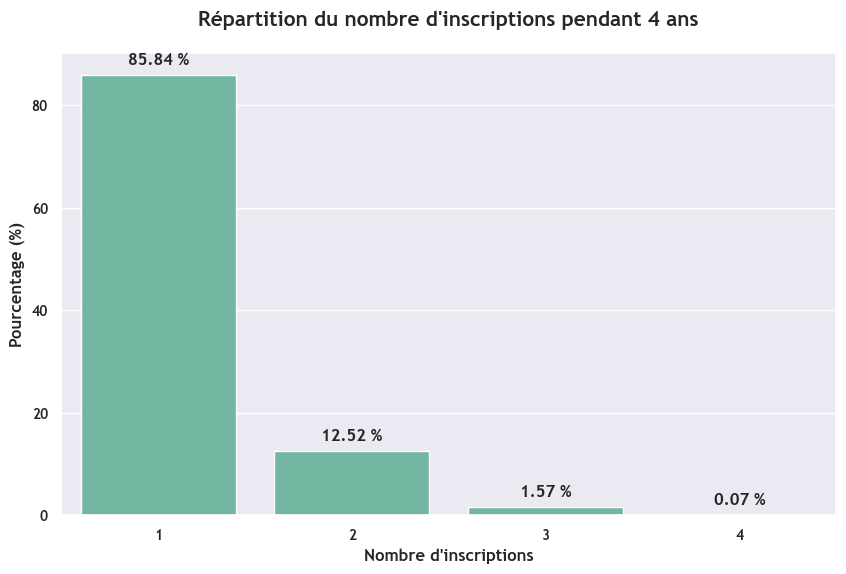

In [335]:
# grouped by the number of courses they have done
df_by_user_graph = df_by_user.groupby('nb_courses').size().reset_index(name='nb_students')
df_by_user_graph['pct'] = df_by_user_graph.nb_students / df_by_user_graph.nb_students.sum() * 100

makeBarplot(
    df_by_user_graph,
    x='nb_courses',
    xLabel="Nombre d'inscriptions",
    y='pct',
    yLabel="Pourcentage (%)",
    title="Répartition du nombre d'inscriptions pendant 4 ans",
    bar_label_format="%.2f %%"
)

plt.show()

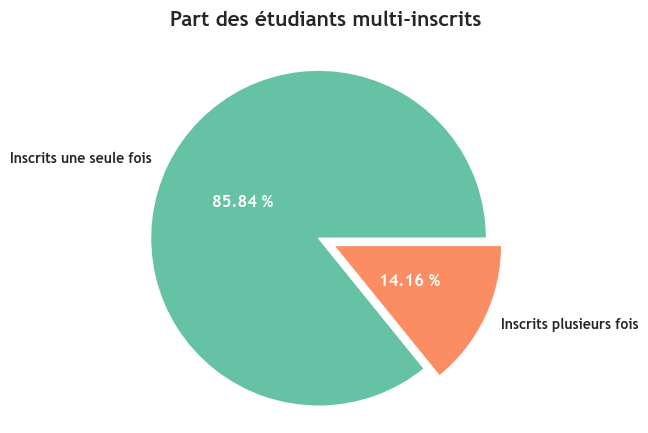

In [336]:
# with pie chart

pct_once = df_by_user_graph.loc[df_by_user_graph.nb_courses == 1, 'pct'].values[0]

df_by_user_pie = pd.DataFrame({
    "nb_courses": ['once', "multiple"],
    'pct': [pct_once, 100 - pct_once]
})

explode = (0.05, 0.05)

widget, label, pct = plt.pie(
    df_by_user_pie.pct,
    labels=['Inscrits une seule fois', 'Inscrits plusieurs fois'],
    autopct="%.2f %%",
    pctdistance=0.5,
    explode=explode
)

makeTitle('Part des étudiants multi-inscrits')
makePctLabel(pct)

plt.axis('equal')
plt.show()